In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
from slope2noise.utils import octave_filtering
from pathlib import Path
from numpy.typing import ArrayLike
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
import DecayFitNet.python.toolbox as decayfitnet
import DecayFitNet.python.toolbox.DecayFitNetToolbox as dfn

from slope2noise.utils import schroeder_backward_int, decay_kernel
from slope2noise.dataclass import *
from slope2noise.generate import *

Load parameters from Georg's dataset 

In [3]:
dataset_path = Path("../../../resources/Georg_3room_FDTD/Common_Slope_Analysis_Results").resolve()
# load the impulse responses
file_path = Path("../../../resources/Georg_3room_FDTD/srirs.mat").resolve()

with h5py.File(file_path, 'r') as mat_file:
    # Get the dataset
    srirs = mat_file['srirDataset']
    # get the impulse responses
    fs = int(np.squeeze(srirs['fs'][:])) # sampling frequnecy
    L = srirs['srirs'][:].shape[1] # length of the impulse responses
    loc_indx = 680   # location index [0, 838]
    ref_rir = srirs['srirs'][0, :, loc_indx]   # assuming that the omnidirectional is the first channel


Estimate the Decay parameters using DFN at 1000Hz 

In [45]:
time_axis = np.arange(0, L) / fs
f_bands = [125, 250, 500, 1000, 2000, 4000, 8000]
i_band = 4
norm_flag = True
# initialize the decay fit net toolbox
dfn_band = dfn.DecayFitNetToolbox(n_slopes=0, sample_rate=fs, filter_frequencies=[f_bands[i_band]])
# estimate the parameters 
estimated_param, norm_vals_decayfitnet = dfn_band.estimate_parameters(ref_rir, analyse_full_rir=True)
norm_vals = 1 if norm_flag else norm_vals_decayfitnet.squeeze().detach().numpy()

# fit the EDC
ref_edc_decayfitnet = np.sum(decayfitnet.core.decay_model(estimated_param[0],
                                                    estimated_param[1]*norm_vals,
                                                    estimated_param[2]*norm_vals,
                                                    time_axis=time_axis,
                                                    compensate_uli=True,
                                                    backend='np').squeeze, axis=0)
print(ref_edc_decayfitnet.shape)

(4, 128001)


Compare the estimated parameters with those in the dataset

In [35]:
# DecayFitNet finds the optimal number of slopes and set the rest to zero
# pick one random file from the dataset 
filepath = "cs_analysis_results_omni_"+str(f_bands[i_band])+".mat"
# read the mat file
file_path = os.path.join(dataset_path, filepath)
with h5py.File(file_path, 'r') as mfile:
    data = mfile['analysisResults']
    valid_slopes =  np.nonzero(data['tVals_standard'][:, loc_indx])[0]
    valid_slopes_dfn =  np.nonzero(estimated_param[1])[0]
    t_vals_dfn = data['tVals_standard'][valid_slopes, loc_indx] 
    a_vals_dfn =  data['aVals_standard'][valid_slopes, loc_indx] * norm_vals
    n_vals_dfn = data['nVals_standard'][..., loc_indx] * norm_vals
    
    t_vals_cs = np.squeeze(data['commonDecayTimes'][:])
    a_vals_cs =  data['aVals'][...,loc_indx] 
    n_vals_cs = data['nVals'][..., loc_indx]

In [37]:
from importlib import reload
import slope2noise
reload(slope2noise.generate)
from slope2noise.generate import shaped_wgn

print("dataset t_vals: ", t_vals_cs)
print("estimated t_vals: ", estimated_param[0].squeeze()[valid_slopes_dfn])

print("a_vals: ", a_vals_cs)
print("estimated a_vals: ", estimated_param[1].squeeze()[valid_slopes_dfn])

print("n_vals: ", n_vals_cs)
print("estimated n_vals: ", estimated_param[2].squeeze())


_, rir_slope2noise_dfn = shaped_wgn(np.expand_dims(t_vals_dfn, [0, -1]), 
                                np.expand_dims(a_vals_dfn, [0, -1]), 
                                fs, 
                                L,
                                n_vals=np.expand_dims(n_vals_dfn, -1),
                                )

edc_slope2noise_dfn = schroeder_backward_int(rir_slope2noise_dfn.squeeze(), normalize=norm_flag)

_, rir_slope2noise_cs = shaped_wgn(np.expand_dims(t_vals_cs, [0, -1]), 
                                np.expand_dims(a_vals_cs, [0, -1]), 
                                fs, 
                                L,
                                # n_vals=np.expand_dims(n_vals_cs, -1),
                                )
edc_slope2noise_cs = schroeder_backward_int(rir_slope2noise_cs.squeeze(), normalize=norm_flag)

2025-02-06 14:07:20.395 | INFO     | slope2noise.generate:shaped_wgn:98 - Done with kernel generation for slope 1
2025-02-06 14:07:20.402 | INFO     | slope2noise.generate:shaped_wgn:98 - Done with kernel generation for slope 2
2025-02-06 14:07:20.406 | INFO     | slope2noise.generate:shaped_wgn:98 - Done with kernel generation for slope 3
2025-02-06 14:07:20.418 | INFO     | slope2noise.generate:shaped_wgn:98 - Done with kernel generation for slope 1
2025-02-06 14:07:20.422 | INFO     | slope2noise.generate:shaped_wgn:98 - Done with kernel generation for slope 2
2025-02-06 14:07:20.426 | INFO     | slope2noise.generate:shaped_wgn:98 - Done with kernel generation for slope 3


dataset t_vals:  [0.675 1.575 3.325]
estimated t_vals:  [1.2693211 1.2693211]
a_vals:  [4.85373790e-14 6.23235617e-02 1.59858930e-03]
estimated a_vals:  [0.937201 0.937201]
n_vals:  [3.34903759e-06]
estimated n_vals:  3.400021e-17


Compare the EDC from SRIR filtered at 1000 with the fitted EDC

/var/folders/gv/11c9ydl12cjg8htlq2jf1f9h0000gp/T/ipykernel_29638/2940680034.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.plot(time_axis, 10*np.log10(ref_edc_decayfitnet.squeeze()), '-.', label='EDC fitted on Decay Fit Net estimations')


ValueError: x and y must have same first dimension, but have shapes (128001,) and (4, 128001)

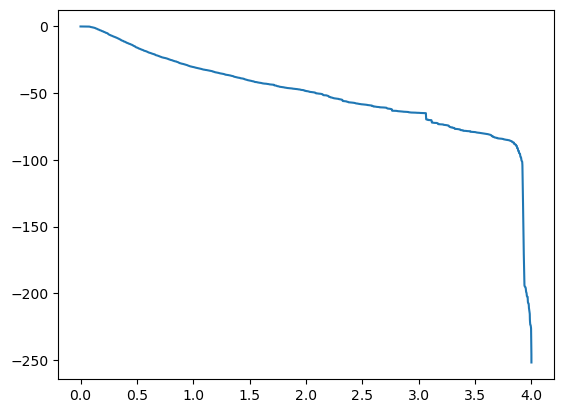

In [43]:
# extract the 1000 Hz band from the impulse response
reload(slope2noise.utils)
from slope2noise.utils import octave_filtering

ref_rir_filt = octave_filtering(ref_rir, fs, f_bands, compensate_filter_energy=True)[:, i_band]
# Use schroeder backward integration to estimate the EDC
ref_filt_int = schroeder_backward_int(ref_rir_filt.squeeze(), normalize=norm_flag)

plt.plot(time_axis, 10*np.log10(ref_filt_int), '-', label='RIR backward integration EDC')
plt.plot(time_axis, 10*np.log10(ref_edc_decayfitnet.squeeze()), '-.', label='EDC fitted on Decay Fit Net estimations')
plt.plot(time_axis, 10*np.log10(edc_slope2noise_dfn), '--', label='EDC from slope2noise shaping with DFN parameters')
plt.plot(time_axis, 10*np.log10(edc_slope2noise_cs), '--', label='EDC from slope2noise shaping with CS parameters')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.ylim(-100, 10)
plt.legend()
plt.grid(True)
plt.show()